# Customer Churn Prediction — Machine Learning Models

**Notebook 02 | Binary Classification**

---

## Overview

This notebook trains and evaluates two classification models to predict **customer churn** — whether a customer will leave the service or not.

The pipeline follows these steps:

1. **Setup & Data Preprocessing** — Load cleaned data and apply feature encoding
2. **Train / Test Split** — Partition data into training and evaluation sets
3. **Model 1: Decision Tree** — Train, predict, and evaluate
4. **Model 2: Random Forest** — Train, predict, and evaluate
5. **Model Comparison** — ROC Curves, Confusion Matrices, Feature Importance
6. **Environment Info** — Library versions for reproducibility

> **Target variable:** `Churn` — `1` = customer churned, `0` = customer stayed

---
## 1. Setup & Data Preprocessing

### Why Encoding?

Machine learning models require **numerical input**. Our raw dataset contains categorical columns (e.g., `gender`, `Contract`, `PaymentMethod`). We apply three encoding strategies:

| Encoding Type | When to Use | Example |
|---|---|---|
| **Binary (0/1)** | Two-category columns | `Yes` → `1`, `No` → `0` |
| **Ordinal** | Categories with a natural order | `Month-to-month` → `0`, `One year` → `1`, `Two year` → `2` |
| **One-Hot (get_dummies)** | No natural order, multiple categories | `PaymentMethod`, `InternetService` |

> **Note:** `drop_first=True` in `get_dummies` drops one dummy column to avoid the **dummy variable trap** (perfect multicollinearity).

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

# Consistent plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (8, 5)

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


In [15]:
# ── Load the cleaned dataset ──────────────────────────────────────────────────
df = pd.read_csv('cleaned_data.csv')
df_encoded = df.copy()

# ── 1. Binary Encoding (Yes/No → 1/0) ────────────────────────────────────────
binary_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn'
]

for col in binary_cols:
    if col in df_encoded.columns:
        if col == 'gender':
            df_encoded[col] = df_encoded[col].map({'Female': 1, 'Male': 0})
        else:
            df_encoded[col] = df_encoded[col].map({'Yes': 1, 'No': 0})

# ── 2. Ordinal Encoding (Contract has a natural order) ────────────────────────
if 'Contract' in df_encoded.columns:
    df_encoded['Contract'] = df_encoded['Contract'].map({
        'Month-to-month': 0,
        'One year': 1,
        'Two year': 2
    })

# ── 3. One-Hot Encoding (no natural order) ────────────────────────────────────
cols_to_dummify = ['PaymentMethod', 'InternetService']
existing_cols = [c for c in cols_to_dummify if c in df_encoded.columns]
df_encoded = pd.get_dummies(df_encoded, columns=existing_cols, drop_first=True)

print("✅ Data loaded and encoded successfully.")
print(f"   Dataset shape: {df_encoded.shape[0]} rows × {df_encoded.shape[1]} columns")

✅ Data loaded and encoded successfully.
   Dataset shape: 7043 rows × 23 columns


---
## 2. Train / Test Split

We hold out **20%** of the data as an unseen **test set** to evaluate how well the model generalises to new customers.

### Key Parameters

| Parameter | Value | Reason |
|---|---|---|
| `test_size` | `0.20` | 80/20 is a standard split for medium-sized datasets |
| `random_state` | `42` | Ensures reproducibility across runs |
| `stratify=y` | Enabled | Preserves the original churn ratio in both sets — critical for **imbalanced classes** |

> **Why stratify?** If ~26% of customers churn in the full dataset, both train and test sets should also contain ~26% churners. Without this, random splits can produce a test set that is unrepresentative.

In [16]:
# ── Define Features (X) and Target (y) ───────────────────────────────────────
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# ── Stratified Split ──────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("✅ Data split complete.")
print(f"   Training set : {X_train.shape[0]} customers ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"   Test set     : {X_test.shape[0]} customers ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"   Churn rate   — Train: {y_train.mean()*100:.1f}% | Test: {y_test.mean()*100:.1f}%")

✅ Data split complete.
   Training set : 5634 customers (80%)
   Test set     : 1409 customers (20%)
   Churn rate   — Train: 26.5% | Test: 26.5%


---
## 3. Model 1: Decision Tree Classifier

A Decision Tree recursively splits the dataset by asking feature-based questions (e.g., *"Is the contract month-to-month?"*) to separate churners from non-churners.

### Strengths & Weaknesses

| ✅ Strengths | ⚠️ Weaknesses |
|---|---|
| Highly interpretable — you can visualise the tree | Prone to **overfitting** on training data |
| No feature scaling required | Unstable — small data changes → different trees |
| Handles mixed data types natively | Deep trees lose generalisation ability |

> **`max_depth=5`** caps the tree at 5 levels, trading some training accuracy for better generalisation on unseen data.

In [17]:
# ── Initialise ────────────────────────────────────────────────────────────────
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)

# ── Train ─────────────────────────────────────────────────────────────────────
dt_model.fit(X_train, y_train)

# ── Predict on the unseen test set ────────────────────────────────────────────
dt_predictions = dt_model.predict(X_test)

# ── Evaluate ──────────────────────────────────────────────────────────────────
print("=" * 45)
print("     DECISION TREE — PERFORMANCE REPORT")
print("=" * 45)
print(f"  Accuracy : {accuracy_score(y_test, dt_predictions) * 100:.2f}%")
print()
print(classification_report(y_test, dt_predictions, target_names=['Stayed', 'Churned']))

     DECISION TREE — PERFORMANCE REPORT
  Accuracy : 79.91%

              precision    recall  f1-score   support

      Stayed       0.85      0.88      0.87      1035
     Churned       0.63      0.58      0.61       374

    accuracy                           0.80      1409
   macro avg       0.74      0.73      0.74      1409
weighted avg       0.79      0.80      0.80      1409



### 3a. Decision Tree — Confusion Matrix

The confusion matrix breaks predictions into four categories:

| | Predicted: Stayed | Predicted: Churned |
|---|---|---|
| **Actual: Stayed** | True Negative (TN) ✅ | False Positive (FP) ❌ |
| **Actual: Churned** | False Negative (FN) ❌ | True Positive (TP) ✅ |

> In churn prediction, **False Negatives are costly** — these are churners we failed to identify and therefore couldn't retain.

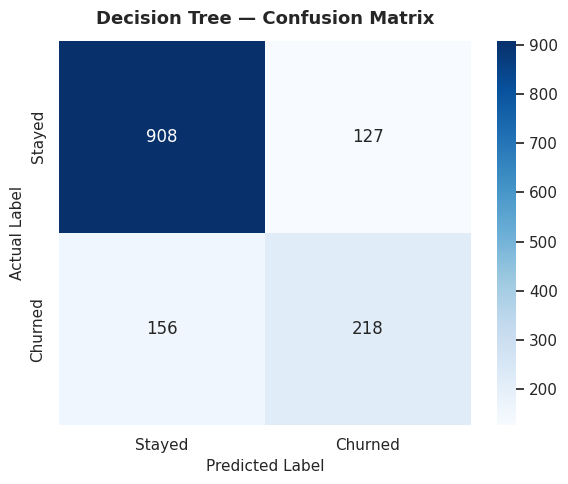

In [18]:
fig, ax = plt.subplots(figsize=(6, 5))

cm_dt = confusion_matrix(y_test, dt_predictions)
sns.heatmap(
    cm_dt, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Stayed', 'Churned'],
    yticklabels=['Stayed', 'Churned'],
    ax=ax
)
ax.set_title('Decision Tree — Confusion Matrix', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('Actual Label', fontsize=11)
plt.tight_layout()
plt.show()

---
## 4. Model 2: Random Forest Classifier

Random Forest is an **ensemble method** that trains many decision trees on random subsets of the data and features, then combines their votes. This reduces the variance (overfitting) inherent to single trees.

### How It Reduces Overfitting

```
Single Decision Tree  →  Low bias, HIGH variance (memorises noise)
Random Forest (100 trees)  →  Low bias, LOWER variance (averages out noise)
```

| Parameter | Value | Reason |
|---|---|---|
| `n_estimators` | `100` | 100 trees — good balance of accuracy vs. compute time |
| `max_depth` | `7` | Slightly deeper than the single tree, safe because bagging reduces overfitting |
| `random_state` | `42` | Reproducibility |

> **Bagging (Bootstrap Aggregating):** Each tree is trained on a random sample *with replacement*, so no two trees see exactly the same data.

In [19]:
# ── Initialise ────────────────────────────────────────────────────────────────
rf_model = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42)

# ── Train ─────────────────────────────────────────────────────────────────────
rf_model.fit(X_train, y_train)

# ── Predict on the unseen test set ────────────────────────────────────────────
rf_predictions = rf_model.predict(X_test)

# ── Evaluate ──────────────────────────────────────────────────────────────────
print("=" * 45)
print("     RANDOM FOREST — PERFORMANCE REPORT")
print("=" * 45)
print(f"  Accuracy : {accuracy_score(y_test, rf_predictions) * 100:.2f}%")
print()
print(classification_report(y_test, rf_predictions, target_names=['Stayed', 'Churned']))

     RANDOM FOREST — PERFORMANCE REPORT
  Accuracy : 80.34%

              precision    recall  f1-score   support

      Stayed       0.83      0.91      0.87      1035
     Churned       0.68      0.50      0.57       374

    accuracy                           0.80      1409
   macro avg       0.76      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



### 4a. Random Forest — Confusion Matrix

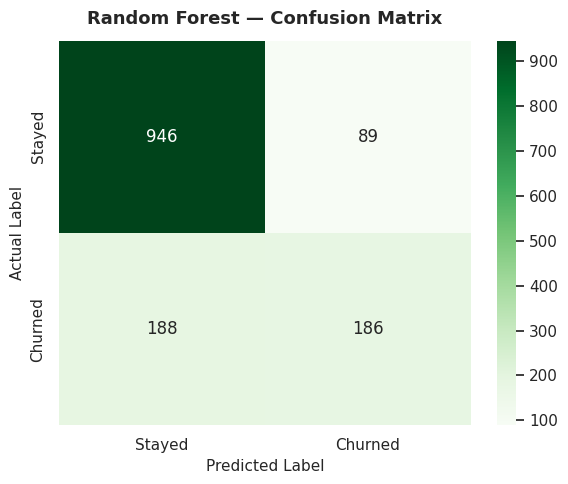

In [20]:
fig, ax = plt.subplots(figsize=(6, 5))

cm_rf = confusion_matrix(y_test, rf_predictions)
sns.heatmap(
    cm_rf, annot=True, fmt='d', cmap='Greens',
    xticklabels=['Stayed', 'Churned'],
    yticklabels=['Stayed', 'Churned'],
    ax=ax
)
ax.set_title('Random Forest — Confusion Matrix', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('Actual Label', fontsize=11)
plt.tight_layout()
plt.show()

---
## 5. Model Comparison

### 5a. ROC Curves

The **ROC (Receiver Operating Characteristic) curve** plots the True Positive Rate vs. False Positive Rate at every classification threshold.

- **AUC = 1.0** → Perfect model
- **AUC = 0.5** → Random guessing (useless)
- **Higher AUC** → Better model at distinguishing churners from non-churners

> AUC is threshold-independent, making it a more reliable metric than accuracy alone — especially for **imbalanced datasets** like churn.

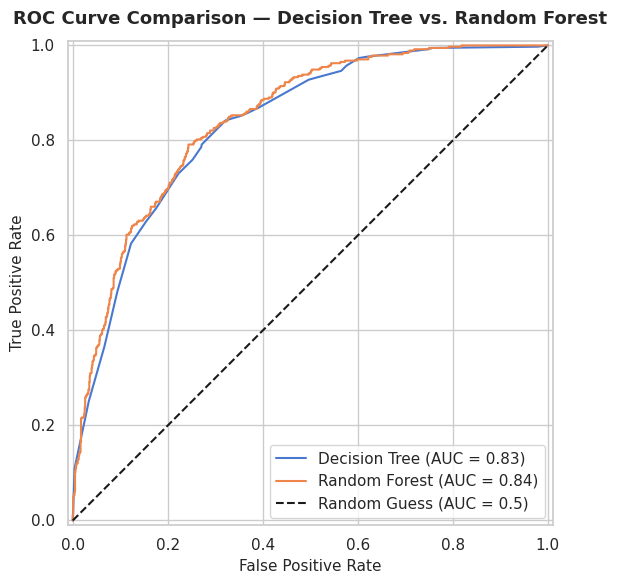

Decision Tree AUC : 0.8344
Random Forest AUC : 0.8450


In [21]:
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_estimator(dt_model, X_test, y_test, name="Decision Tree", ax=ax)
RocCurveDisplay.from_estimator(rf_model, X_test, y_test, name="Random Forest", ax=ax)

ax.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5)')
ax.set_title('ROC Curve Comparison — Decision Tree vs. Random Forest',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

dt_auc = roc_auc_score(y_test, dt_model.predict_proba(X_test)[:, 1])
rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])
print(f"Decision Tree AUC : {dt_auc:.4f}")
print(f"Random Forest AUC : {rf_auc:.4f}")

### 5b. Feature Importance — Decision Tree

Feature importance shows **how much each feature contributed** to the splits across the tree. Higher importance → more discriminative feature.

> Features with near-zero importance can often be removed without performance loss — useful for dimensionality reduction.

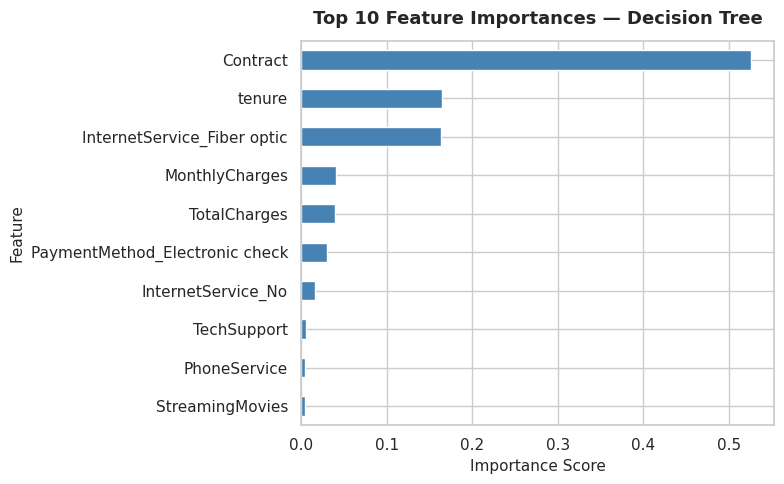

In [22]:
importances_dt = pd.Series(dt_model.feature_importances_, index=X_train.columns)
top10_dt = importances_dt.sort_values().tail(10)

fig, ax = plt.subplots(figsize=(8, 5))
top10_dt.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 10 Feature Importances — Decision Tree', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)
plt.tight_layout()
plt.show()

### 5c. Feature Importance — Random Forest

Random Forest's feature importances are **averaged across all 100 trees**, making them more stable and reliable than those from a single Decision Tree.

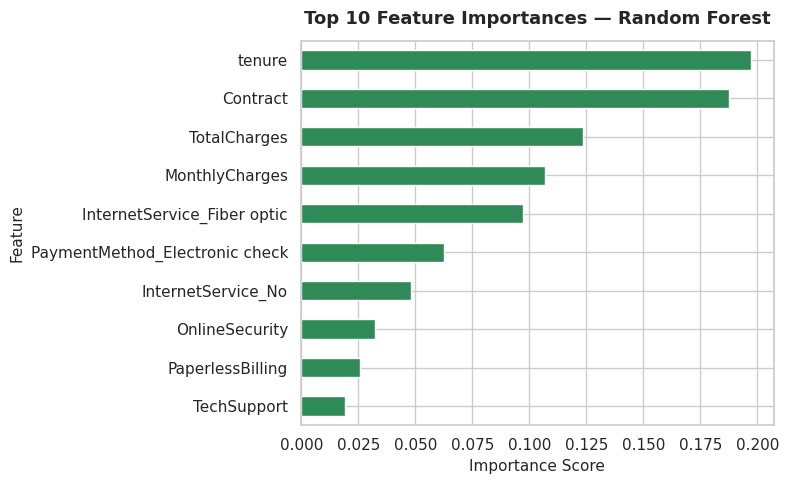

In [23]:
importances_rf = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top10_rf = importances_rf.sort_values().tail(10)

fig, ax = plt.subplots(figsize=(8, 5))
top10_rf.plot(kind='barh', ax=ax, color='seagreen')
ax.set_title('Top 10 Feature Importances — Random Forest', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)
plt.tight_layout()
plt.show()

---
## 6. Environment Info

Run this cell to generate the contents of your `requirements.txt` for reproducibility.

In [24]:
import sklearn

print("# requirements.txt")
print(f"pandas=={pd.__version__}")
print(f"numpy=={np.__version__}")
print(f"scikit-learn=={sklearn.__version__}")
print(f"seaborn=={sns.__version__}")
print(f"matplotlib=={plt.matplotlib.__version__}")

# requirements.txt
pandas==2.2.2
numpy==2.0.2
scikit-learn==1.6.1
seaborn==0.13.2
matplotlib==3.10.0
